In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# 1. LOAD DATA
df = pd.read_csv("./winequality-red.csv")

X = df.drop("quality", axis=1).values
y_raw = df["quality"].values

# 2. GỘP LỚP (KEY STEP)
def merge_quality(q):
    if q <= 4:
        return 0      # Low
    elif q <= 6:
        return 1      # Medium
    else:
        return 2      # High

y = np.array([merge_quality(q) for q in y_raw])

classes = np.array(["Low", "Medium", "High"])
num_classes = len(classes)

print("Class distribution after merge:")
for i, c in enumerate(classes):
    print(c, np.sum(y == i))

# 3. ONE-HOT ENCODING
def one_hot(y, num_class):
    m = len(y)
    oh = np.zeros((m, num_class))
    oh[np.arange(m), y] = 1
    return oh

# 4. SPLIT + SCALE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Y_train = one_hot(y_train, num_classes)

# 5. SOFTMAX + LOSS
def softmax(z):
    z = z - np.max(z)
    exp = np.exp(z)
    return exp / np.sum(exp)

def cross_entropy(y, y_hat):
    return -np.sum(y * np.log(y_hat + 1e-9))


# 6. TRAIN SOFTMAX REGRESSION
def train_softmax(X, Y, lr=0.05, epochs=800):
    m, n = X.shape
    k = Y.shape[1]

    Xb = np.hstack([np.ones((m,1)), X])
    theta = np.random.randn(k, n+1) * 0.01
    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for i in range(m):
            x = Xb[i].reshape(-1,1)
            y = Y[i].reshape(-1,1)

            z = theta @ x
            y_hat = softmax(z)

            loss = cross_entropy(y, y_hat)
            total_loss += loss

            grad = (y_hat - y) @ x.T
            theta -= lr * grad

        losses.append(total_loss / m)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss = {losses[-1]:.4f}")

    return theta, losses

theta, losses = train_softmax(X_train, Y_train)

# 7. PREDICT
def predict(X, theta):
    m = X.shape[0]
    Xb = np.hstack([np.ones((m,1)), X])
    preds = []

    for i in range(m):
        z = theta @ Xb[i].reshape(-1,1)
        y_hat = softmax(z)
        preds.append(np.argmax(y_hat))

    return np.array(preds)

y_pred = predict(X_test, theta)





Class distribution after merge:
Low 63
Medium 1319
High 217
Epoch 0, Loss = 0.4901
Epoch 100, Loss = 0.4649
Epoch 200, Loss = 0.4649
Epoch 300, Loss = 0.4649
Epoch 400, Loss = 0.4649
Epoch 500, Loss = 0.4649
Epoch 600, Loss = 0.4649
Epoch 700, Loss = 0.4649


In [3]:
# 8. METRICS
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))



Accuracy: 0.825

Classification Report:
              precision    recall  f1-score   support

         Low       0.33      0.08      0.12        13
      Medium       0.87      0.93      0.90       264
        High       0.51      0.42      0.46        43

    accuracy                           0.82       320
   macro avg       0.57      0.47      0.49       320
weighted avg       0.80      0.82      0.81       320



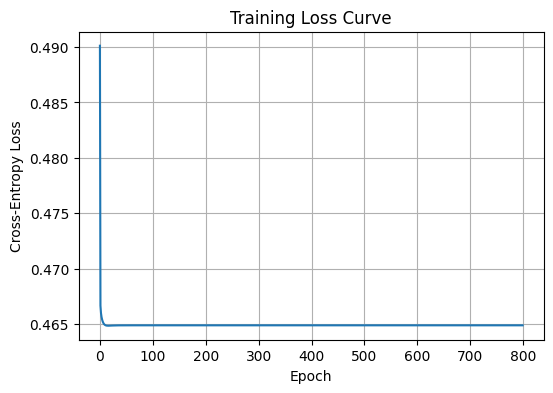

In [4]:
# 9. LOSS CURVE
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

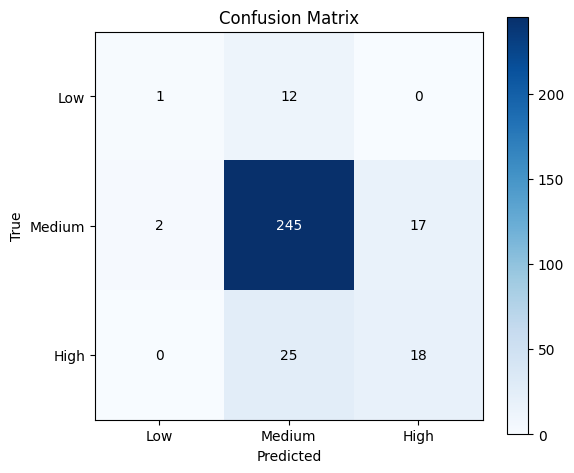

In [5]:

# 10. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()